# Exercise 7.2e solution

There are different ways to solve ODEs analytically. In this case, we will be solving the differential equation using **Laplace Transforms**, but feel free to use any other method (like an integrating factor)—you should end up with the exact same solution.

We will solve the following ODE analytically:

$$
\frac{\mathrm{d}V}{\mathrm{d}t} = \frac{V_{\mathrm{target}} - V}{C_{\mathrm{m}} R_{\mathrm{s}}}
$$

We start by taking the Laplace transform on both the left and right sides of the equation:

$$
\mathcal{L}\left(\frac{\mathrm{d}V}{\mathrm{d}t}\right) = s \cdot V(s) - V(0)
$$

$$
\mathcal{L}\left(\frac{V_{\mathrm{target}} - V}{C_{\mathrm{m}} R_{\mathrm{s}}}\right) = \frac{V_{\mathrm{target}}(s) - V(s)}{C_{\mathrm{m}} R_{\mathrm{s}}}
$$

Thus, we can set them equal to each other:

$$
s V(s) - V(0) = \frac{V_{\mathrm{target}}(s) - V(s)}{C_{\mathrm{m}} R_{\mathrm{s}}}
$$

We can now multiply the entire equation by $C_{\mathrm{m}} R_{\mathrm{s}}$ to clear the denominator:

$$
s C_{\mathrm{m}} R_{\mathrm{s}} V(s) - C_{\mathrm{m}} R_{\mathrm{s}} V(0) = V_{\mathrm{target}}(s) - V(s)
$$

Next, we group all terms containing $V(s)$ on the left side of the equation and move $V(0)$ to the right side:

$$
s C_{\mathrm{m}} R_{\mathrm{s}} V(s) + V(s) = V_{\mathrm{target}}(s) + C_{\mathrm{m}} R_{\mathrm{s}} V(0)
$$

Factoring out $V(s)$ gives:

$$
(s C_{\mathrm{m}} R_{\mathrm{s}} + 1) V(s) = V_{\mathrm{target}}(s) + C_{\mathrm{m}} R_{\mathrm{s}} V(0)
$$

We divide by $(s C_{\mathrm{m}} R_{\mathrm{s}} + 1)$ to obtain an explicit expression for $V(s)$:

$$
V(s) = \frac{V_{\mathrm{target}}(s)}{s C_{\mathrm{m}} R_{\mathrm{s}} + 1} + \frac{C_{\mathrm{m}} R_{\mathrm{s}} V(0)}{s C_{\mathrm{m}} R_{\mathrm{s}} + 1}
$$

This expression can be rewritten in a slightly different way, which will be much more helpful for calculating the inverse Laplace transform. We divide the numerator and denominator of each fraction by $C_{\mathrm{m}} R_{\mathrm{s}}$:

$$
V(s) = \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}} \cdot \frac{V_{\mathrm{target}}(s)}{s + \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}}} + \frac{V(0)}{s +  \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}}}
$$

With the help of standard inverse Laplace transform properties, specifically the exponential decay rule and the convolution theorem:

$$
\mathcal{L}^{-1}\left(\frac{1}{s + a}\right) = e^{-at}
$$

$$
\mathcal{L}^{-1}\left(F(s) \cdot G(s)\right) = \int_{0}^{t} f(u) \cdot g(t-u) \, \mathrm{d}u
$$

We can calculate the inverse Laplace transform of our two terms separately. For the initial condition term:

$$
\mathcal{L}^{-1}\left(\frac{V(0)}{s +  \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}}}\right) = V(0) \cdot e^{-\frac{t}{C_{\mathrm{m}} R_{\mathrm{s}}}}
$$

For the target potential term (using convolution):

$$
\mathcal{L}^{-1}\left(\frac{V_{\mathrm{target}}(s)}{s + \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}}}\right) = \int_{0}^{t} V_{\mathrm{target}}(u) \cdot e^{-\frac{t - u}{C_{\mathrm{m}} R_{\mathrm{s}}}} \, \mathrm{d}u = e^{-\frac{t}{C_{\mathrm{m}} R_{\mathrm{s}}}} \int_{0}^{t} V_{\mathrm{target}}(u) \cdot e^{\frac{u}{C_{\mathrm{m}} R_{\mathrm{s}}}} \, \mathrm{d}u
$$

Putting it all together, we obtain the final analytical solution for our ODE:

$$
V(t) = V(0) \cdot e^{-\frac{t}{C_{\mathrm{m}} R_{\mathrm{s}}}} + \frac{1}{C_{\mathrm{m}} R_{\mathrm{s}}} \cdot e^{-\frac{t}{C_{\mathrm{m}} R_{\mathrm{s}}}} \int_{0}^{t} V_{\mathrm{target}}(u) \cdot e^{\frac{u}{C_{\mathrm{m}} R_{\mathrm{s}}}} \, \mathrm{d}u
$$

Because $V_{\mathrm{target}}$ is a piecewise constant function in this exercise, you would need to split the integral at the boundaries of the piecewise intervals when evaluating the solution analytically. If you plot this exact analytical solution, you will see it perfectly matches the numerical solution computed by `solve_ivp`:


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def V_target(t):
    return -80 + 40 * (t > 2) * (t < 6)


def rhs(t, V, Cm, Rs):
    dV_dt = (V_target(t) - V) / (Cm * Rs)
    return dV_dt


# Define time array
time = (0, 10)

# Define parameters
Cm = 0.05  # nF
Rs = 10  # MOhm
params = (Cm, Rs)

# Define initial condition
y0 = (-80,)

# Call solve_ivp
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.1)
# ----------------------------------------------

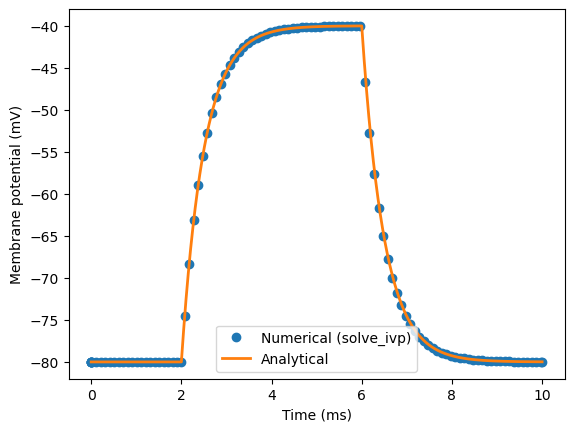

In [ ]:
# Extract numerical solution variables for comparison
t_num = solution.t
(V_num,) = solution.y

# Create a dense time array for a smooth analytical plot
t = np.linspace(0, 10, 10000)
V_a = []

# Evaluate the piecewise analytical solution
for idx, i in enumerate(t):
    if i < 2:
        V_a.append(
            -80 * np.exp(-i / (Cm * Rs))
            + np.exp(-i / (Cm * Rs)) * (np.exp(i / (Cm * Rs)) * -80 - -80)
        )
    elif i > 2 and i < 6:
        V_a.append(
            -80 * np.exp(-i / (Cm * Rs))
            + np.exp(-i / (Cm * Rs))
            * (
                np.exp(i / (Cm * Rs)) * -40
                - np.exp(2 / (Cm * Rs)) * -40
                + np.exp(2 / (Cm * Rs)) * -80
                - np.exp(0 / (Cm * Rs)) * -80
            )
        )
    else:
        V_a.append(
            -80 * np.exp(-i / (Cm * Rs))
            + np.exp(-i / (Cm * Rs))
            * (
                np.exp(i / (Cm * Rs)) * -80
                - np.exp(6 / (Cm * Rs)) * -80
                + np.exp(6 / (Cm * Rs)) * -40
                - np.exp(2 / (Cm * Rs)) * -40
                + np.exp(2 / (Cm * Rs)) * -80
                - np.exp(0 / (Cm * Rs)) * -80
            )
        )

# Plot both the numerical and analytical solutions to verify they match
plt.plot(t_num, V_num, "o", label="Numerical (solve_ivp)")
plt.plot(t, V_a, "-", linewidth=2, label="Analytical")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.legend()
plt.show()